In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("sales.csv")

In [3]:
df.head()

,Order_ID,Date,Month,Year,Customer_ID,Product_ID,Category,Quantity,Unit_Price,Discount,Sales_Amount
0,1,2025-09-21,9,2025,C093,P209,Herbs,1,9.37,0.15,7.96
1,1,2025-09-21,9,2025,C093,P093,B Formulations,4,27.65,0.15,94.01
2,1,2025-09-21,9,2025,C093,P098,D3 Formulations,6,8.72,0.15,44.47
3,1,2025-09-21,9,2025,C093,P149,Multiple Formulas,1,32.48,0.15,27.61
4,1,2025-09-21,9,2025,C093,P176,Herbs,4,7.50,0.15,25.50


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3629 entries, 0 to 3628
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      3629 non-null   int64  
 1   Date          3629 non-null   object 
 2   Month         3629 non-null   int64  
 3   Year          3629 non-null   int64  
 4   Customer_ID   3629 non-null   object 
 5   Product_ID    3629 non-null   object 
 6   Category      3629 non-null   object 
 7   Quantity      3629 non-null   int64  
 8   Unit_Price    3629 non-null   float64
 9   Discount      3629 non-null   float64
 10  Sales_Amount  3629 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 312.0+ KB


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df["Date"].max()

Timestamp('2025-12-31 00:00:00')

In [8]:
reference_date = df["Date"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2026-01-01 00:00:00')

In [9]:
rfm = df.groupby("Customer_ID").agg({
    "Date": lambda x: (reference_date - x.max()).days,
    "Order_ID": "nunique",
    "Sales_Amount": "sum"
})

In [10]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [11]:
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
C001,51,8,823.30
C002,25,3,461.12
C003,130,6,1018.41
C004,45,7,1107.18
C005,59,4,498.11


In [12]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [13]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [14]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [15]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer_ID,,,,,,
C001,51,8,823.30,3,5,3
C002,25,3,461.12,4,1,1
C003,130,6,1018.41,1,3,4
C004,45,7,1107.18,3,4,4
C005,59,4,498.11,2,1,1


In [16]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [17]:
def segment_customer(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Lost Customers"

    else:
        return "Average Customers"

In [18]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [19]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer_ID,,,,,,,,
C001,51,8,823.30,3,5,3,353,Loyal Customers
C002,25,3,461.12,4,1,1,411,Potential Loyalists
C003,130,6,1018.41,1,3,4,134,At Risk
C004,45,7,1107.18,3,4,4,344,Loyal Customers
C005,59,4,498.11,2,1,1,211,Lost Customers
C006,66,7,1921.63,2,4,5,245,At Risk
C007,96,3,795.75,2,1,3,213,Lost Customers
C008,6,7,1393.73,5,4,4,544,Champions
C009,30,10,2136.93,4,5,5,455,Champions


In [20]:
rfm["Segment"].value_counts()

Segment
At Risk                37
Lost Customers         35
Loyal Customers        33
Champions              27
Potential Loyalists    25
Average Customers      23
Name: count, dtype: int64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

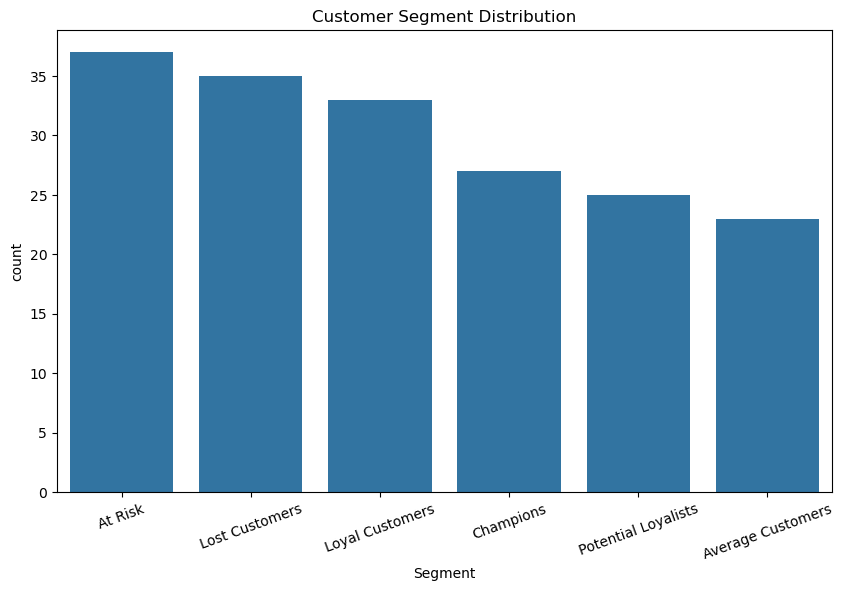

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=20)

plt.show()

In [23]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

segment_revenue

Segment
Champions              42465.83
Loyal Customers        40899.44
At Risk                38322.16
Lost Customers         21429.58
Potential Loyalists    16482.34
Average Customers      13858.80
Name: Monetary, dtype: float64

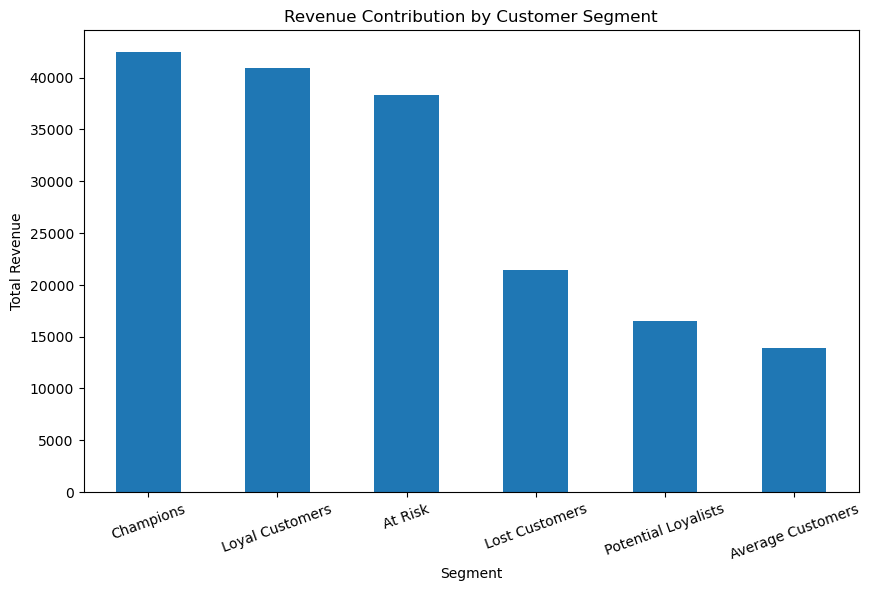

In [24]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=20)

plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [26]:
rfm_clustering = rfm[["Recency", "Frequency", "Monetary"]]

In [27]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_clustering)

In [28]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans.fit(rfm_scaled)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=42)

In [29]:
rfm["Cluster"] = kmeans.labels_

In [30]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
Customer_ID,,,,,,,,,
C001,51,8,823.30,3,5,3,353,Loyal Customers,2
C002,25,3,461.12,4,1,1,411,Potential Loyalists,1
C003,130,6,1018.41,1,3,4,134,At Risk,2
C004,45,7,1107.18,3,4,4,344,Loyal Customers,2
C005,59,4,498.11,2,1,1,211,Lost Customers,1


In [32]:
cluster_summary = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,40.575000,8.250000,1718.620750
1,84.157895,3.666667,617.173684
2,41.000000,6.000000,908.222055
3,278.300000,2.300000,323.421000


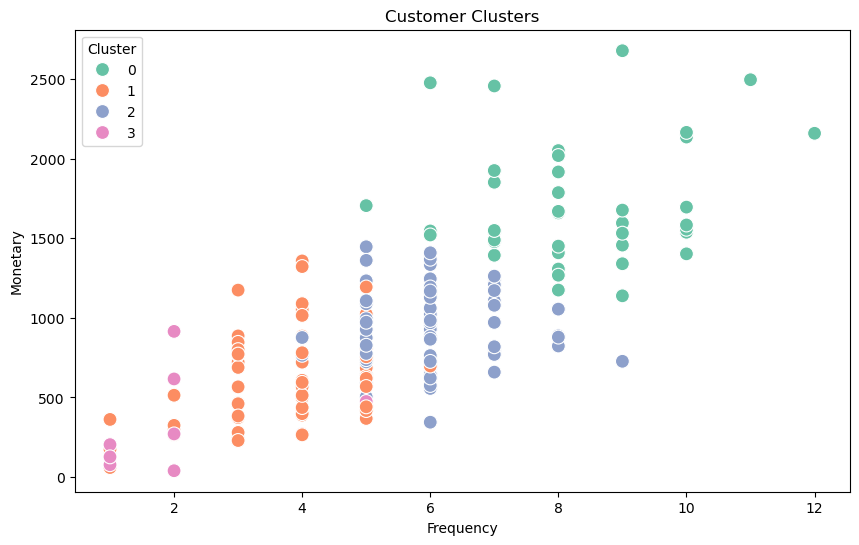

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("Customer Clusters")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()